# Anomaly Detection Using K-Nearest Neighbors (KNN)
## National Parks Visitation Data

This notebook implements anomaly detection using KNN-based methods:
1. **Distance-based**: Points far from their k-nearest neighbors are anomalies
2. **Local Outlier Factor (LOF)**: Measures local density deviation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load Data

In [2]:
df_yearly = pd.read_csv('Datasets/historic_park_data.csv', thousands=',')
df_yearly.fillna(0, inplace=True)
df_yearly['Date'] = pd.to_datetime(df_yearly['Year'].astype(str), format='%Y')
print('Data loaded:', df_yearly.shape)
print('Parks:', df_yearly['ParkName'].nunique())

Data loaded: (5282, 8)
Parks: 63


## 2. Feature Engineering for KNN

In [3]:
def create_knn_features(park_data, target_col='Total', window_size=3):
    df = park_data.copy()
    df = df.sort_values('Date').reset_index(drop=True)
    
    features = []
    dates = []
    values = []
    
    for i in range(len(df)):
        current_val = df.loc[i, target_col]
        feature_vec = [current_val]
        
        # Lag features
        for lag in range(1, window_size + 1):
            feature_vec.append(df.loc[i - lag, target_col] if i >= lag else 0)
        
        # Rolling statistics
        if i >= window_size:
            window_vals = df.loc[i - window_size + 1:i, target_col].values
            feature_vec.extend([np.mean(window_vals), np.std(window_vals) if len(window_vals) > 1 else 0,
                             np.min(window_vals), np.max(window_vals)])
        else:
            feature_vec.extend([current_val, 0, current_val, current_val])
        
        feature_vec.append(df.loc[i, 'Year'])
        feature_vec.append(i)
        
        if i > 0:
            prev_val = df.loc[i - 1, target_col]
            feature_vec.append((current_val - prev_val) / prev_val if prev_val > 0 else 0)
        else:
            feature_vec.append(0)
        
        features.append(feature_vec)
        dates.append(df.loc[i, 'Date'])
        values.append(current_val)
    
    return np.array(features), np.array(dates), np.array(values)

## 3. KNN Anomaly Detection

In [4]:
def detect_anomalies_knn_distance(park_data, target_col='Total', k=5, threshold_percentile=95, window_size=3):
    X, dates, values = create_knn_features(park_data, target_col=target_col, window_size=window_size)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)
    kth_distances = distances[:, k]
    
    threshold = np.percentile(kth_distances, threshold_percentile)
    anomaly_mask = kth_distances > threshold
    
    return {
        'anomaly_mask': anomaly_mask,
        'anomaly_scores': kth_distances,
        'threshold': threshold,
        'dates': dates,
        'values': values,
        'n_anomalies': np.sum(anomaly_mask),
        'anomaly_percentage': 100 * np.sum(anomaly_mask) / len(anomaly_mask)
    }

def detect_anomalies_lof(park_data, target_col='Total', n_neighbors=20, contamination=0.1, window_size=3):
    X, dates, values = create_knn_features(park_data, target_col=target_col, window_size=window_size)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    anomaly_mask = lof.fit_predict(X_scaled) == -1
    lof_scores = -lof.negative_outlier_factor_
    
    return {
        'anomaly_mask': anomaly_mask,
        'anomaly_scores': lof_scores,
        'dates': dates,
        'values': values,
        'n_anomalies': np.sum(anomaly_mask),
        'anomaly_percentage': 100 * np.sum(anomaly_mask) / len(anomaly_mask)
    }

## 4. Analyze Arches and Yosemite

Running KNN anomaly detection for 63 parks...

Analyzing Acadia NP
KNN Distance: 6 anomalies (5.66%)
LOF: 11 anomalies (10.38%)

Analyzing Arches NP
KNN Distance: 5 anomalies (5.21%)
LOF: 10 anomalies (10.42%)


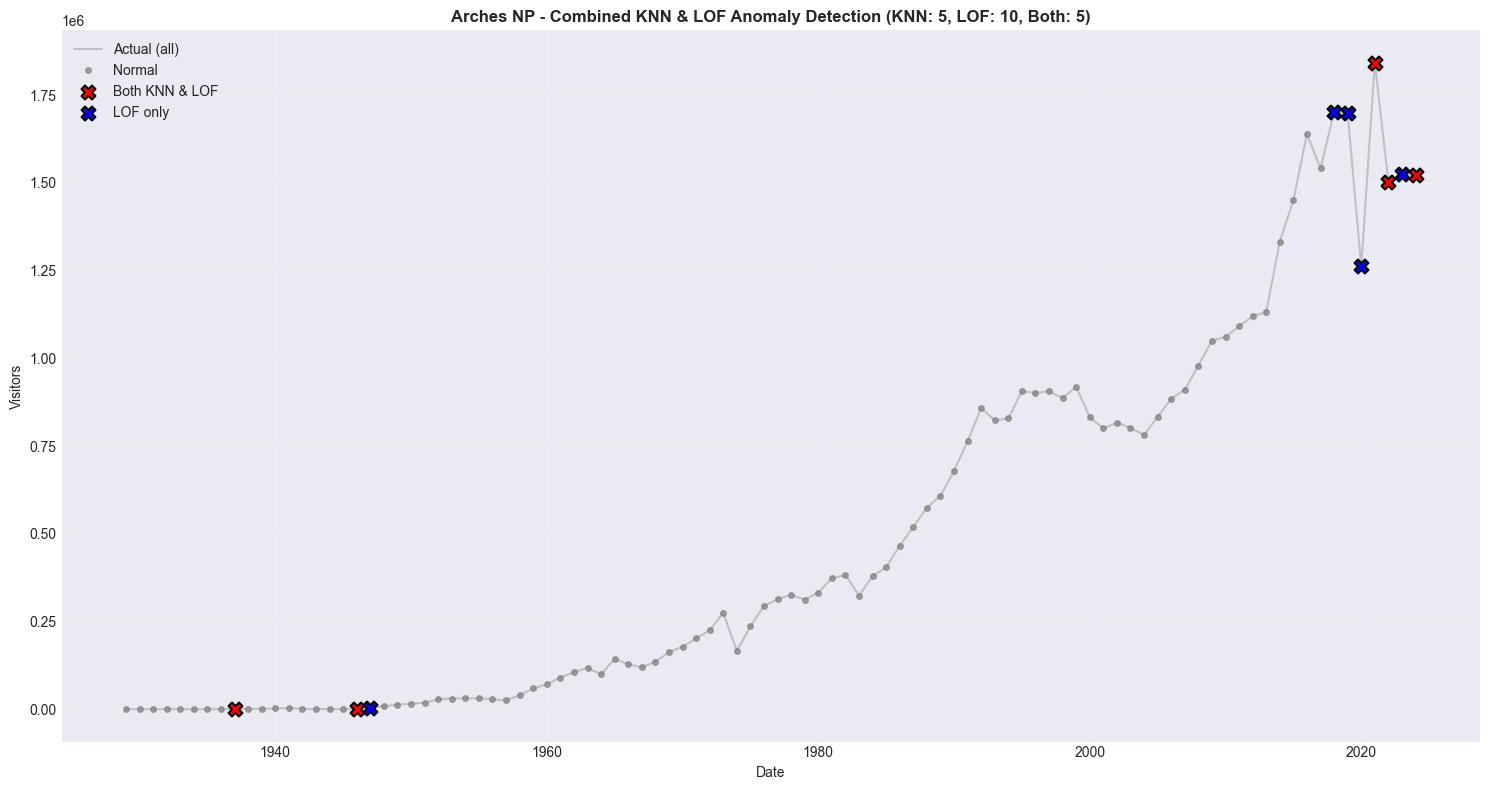


Analyzing Badlands NP
KNN Distance: 5 anomalies (5.81%)
LOF: 9 anomalies (10.47%)

Analyzing Big Bend NP
KNN Distance: 4 anomalies (4.94%)
LOF: 8 anomalies (9.88%)

Analyzing Biscayne NP
KNN Distance: 3 anomalies (5.66%)
LOF: 6 anomalies (11.32%)

Analyzing Black Canyon of the Gunnison NP
KNN Distance: 5 anomalies (5.49%)
LOF: 9 anomalies (9.89%)

Analyzing Bryce Canyon NP
KNN Distance: 5 anomalies (5.21%)
LOF: 10 anomalies (10.42%)

Analyzing Canyonlands NP
KNN Distance: 3 anomalies (5.00%)
LOF: 6 anomalies (10.00%)

Analyzing Capitol Reef NP
KNN Distance: 5 anomalies (5.88%)
LOF: 9 anomalies (10.59%)

Analyzing Carlsbad Caverns NP
KNN Distance: 5 anomalies (4.95%)
LOF: 10 anomalies (9.90%)

Analyzing Channel Islands NP
KNN Distance: 4 anomalies (6.45%)
LOF: 7 anomalies (11.29%)

Analyzing Congaree NP
KNN Distance: 2 anomalies (5.00%)
LOF: 4 anomalies (10.00%)

Analyzing Crater Lake NP
KNN Distance: 6 anomalies (4.96%)
LOF: 12 anomalies (9.92%)

Analyzing Cuyahoga Valley NP
KNN Dista

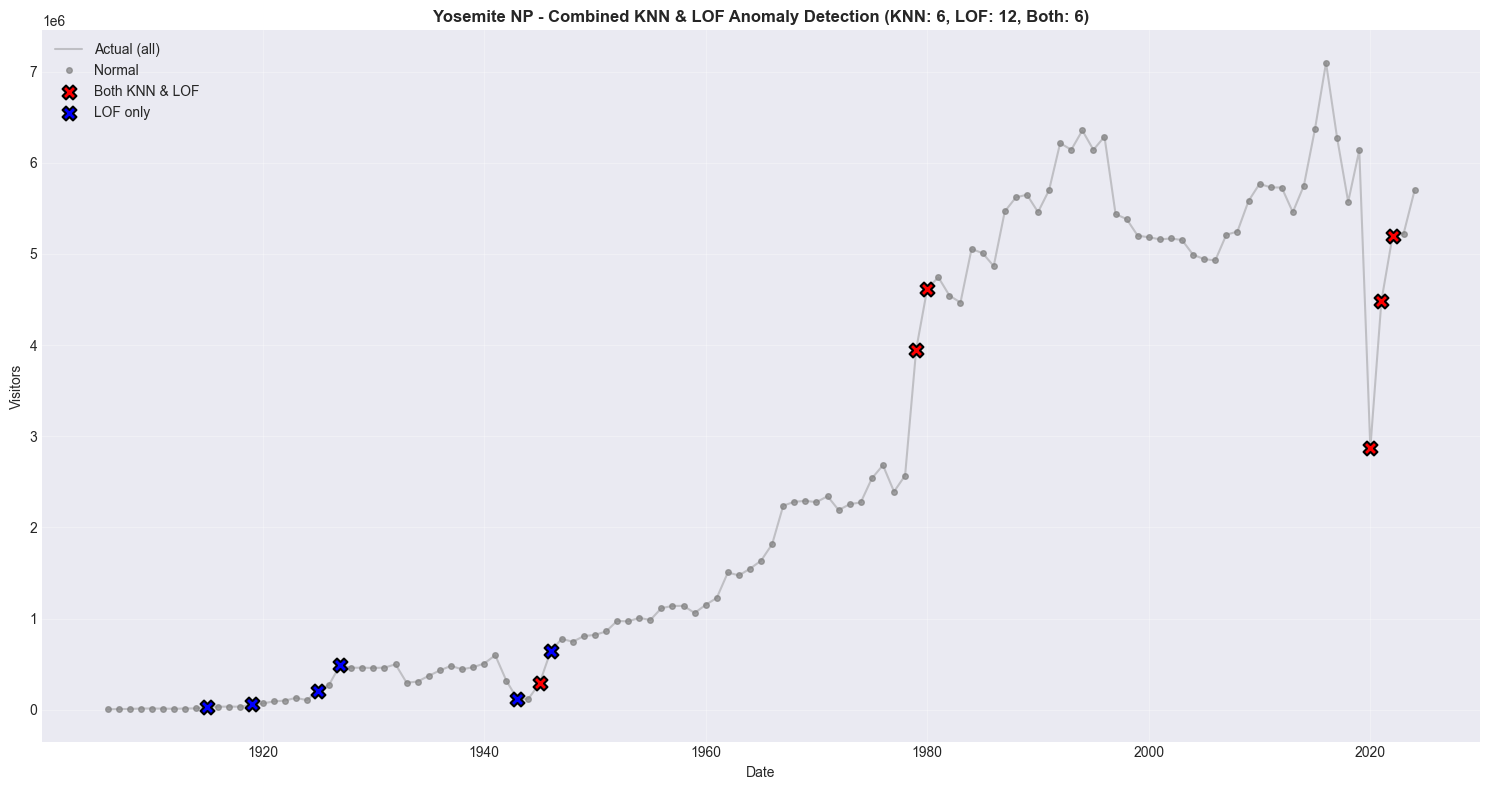


Analyzing Zion NP
KNN Distance: 6 anomalies (5.66%)
LOF: 11 anomalies (10.38%)


In [5]:
# Analyze all parks with KNN (plots only for selected examples)
parks_to_analyze = sorted(df_yearly['ParkName'].unique())
parks_to_plot = ['Arches NP', 'Yosemite NP']  # keep detailed plots only for these

knn_results = {}

print(f'Running KNN anomaly detection for {len(parks_to_analyze)} parks...')

for park_name in parks_to_analyze:
    print(f'\n{"="*60}')
    print(f'Analyzing {park_name}')
    print(f'{"="*60}')
    
    park_data = df_yearly[df_yearly['ParkName'] == park_name].copy()
    park_data = park_data.sort_values('Date').reset_index(drop=True)
    
    # Skip parks with too few data points
    if len(park_data) < 5:
        print('Skipping (too few data points)')
        continue
    
    results_knn = detect_anomalies_knn_distance(park_data, target_col='Total', k=5, threshold_percentile=95)
    results_lof = detect_anomalies_lof(park_data, target_col='Total', n_neighbors=20, contamination=0.1)
    
    print(f'KNN Distance: {results_knn["n_anomalies"]} anomalies ({results_knn["anomaly_percentage"]:.2f}%)')
    print(f'LOF: {results_lof["n_anomalies"]} anomalies ({results_lof["anomaly_percentage"]:.2f}%)')
    
    knn_results[park_name] = {'knn_distance': results_knn, 'lof': results_lof}
    
    # Only plot for selected example parks to avoid clutter
    if park_name in parks_to_plot:
        fig, ax = plt.subplots(1, 1, figsize=(15, 8))
        
        dates = results_knn['dates']
        values = results_knn['values']
        knn_mask = results_knn['anomaly_mask']
        lof_mask = results_lof['anomaly_mask']
        
        # Identify different types of anomalies
        both_mask = knn_mask & lof_mask
        knn_only_mask = knn_mask & ~lof_mask
        lof_only_mask = lof_mask & ~knn_mask
        normal_mask = ~knn_mask & ~lof_mask
        
        # Full actual line (all points)
        ax.plot(dates, values, '-', color='gray', alpha=0.4, label='Actual (all)')
        
        # Normal points
        ax.plot(dates[normal_mask], values[normal_mask], 'o', label='Normal', alpha=0.7, markersize=4, color='gray')
        
        # Anomalies flagged by both methods (red)
        if np.any(both_mask):
            ax.scatter(dates[both_mask], values[both_mask], color='red', s=100, 
                      marker='X', label='Both KNN & LOF', zorder=5, edgecolors='black', linewidth=1.5)
        
        # Anomalies flagged only by KNN (green)
        if np.any(knn_only_mask):
            ax.scatter(dates[knn_only_mask], values[knn_only_mask], color='green', s=100, 
                      marker='X', label='KNN only', zorder=5, edgecolors='black', linewidth=1.5)
        
        # Anomalies flagged only by LOF (blue)
        if np.any(lof_only_mask):
            ax.scatter(dates[lof_only_mask], values[lof_only_mask], color='blue', s=100, 
                      marker='X', label='LOF only', zorder=5, edgecolors='black', linewidth=1.5)
        
        ax.set_title(f'{park_name} - Combined KNN & LOF Anomaly Detection (KNN: {results_knn["n_anomalies"]}, LOF: {results_lof["n_anomalies"]}, Both: {np.sum(both_mask)})', fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Visitors')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## 5. Save Results

In [6]:
import os
base_dir = 'knn_anomalies/results'
knn_dir = os.path.join(base_dir, 'knn')
lof_dir = os.path.join(base_dir, 'lof')
combined_dir = os.path.join(base_dir, 'combined')

for dir_path in [knn_dir, lof_dir, combined_dir]:
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)

for park_name, results in knn_results.items():
    safe_name = park_name.replace(' ', '_').replace('/', '-')
    
    results_knn = results['knn_distance']
    results_lof = results['lof']
    
    knn_mask = results_knn['anomaly_mask']
    lof_mask = results_lof['anomaly_mask']
    combined_mask = knn_mask | lof_mask  # Anomaly if flagged by either method
    
    # KNN results
    df_knn = pd.DataFrame({
        'Date': results_knn['dates'],
        'Year': pd.to_datetime(results_knn['dates']).year,
        'Total': results_knn['values'],
        'Is_Anomaly': knn_mask
    })
    df_knn.to_csv(f'{knn_dir}/{safe_name}.csv', index=False)
    
    # LOF results
    df_lof = pd.DataFrame({
        'Date': results_lof['dates'],
        'Year': pd.to_datetime(results_lof['dates']).year,
        'Total': results_lof['values'],
        'Is_Anomaly': lof_mask
    })
    df_lof.to_csv(f'{lof_dir}/{safe_name}.csv', index=False)
    
    # Combined results (anomaly if flagged by either method)
    df_combined = pd.DataFrame({
        'Date': results_knn['dates'],
        'Year': pd.to_datetime(results_knn['dates']).year,
        'Total': results_knn['values'],
        'Is_Anomaly': combined_mask
    })
    df_combined.to_csv(f'{combined_dir}/{safe_name}.csv', index=False)
    
    print(f'Saved results for {park_name}')

print(f'\nAll results saved to {base_dir}/')

Saved results for Acadia NP
Saved results for Arches NP
Saved results for Badlands NP
Saved results for Big Bend NP
Saved results for Biscayne NP
Saved results for Black Canyon of the Gunnison NP
Saved results for Bryce Canyon NP
Saved results for Canyonlands NP
Saved results for Capitol Reef NP
Saved results for Carlsbad Caverns NP
Saved results for Channel Islands NP
Saved results for Congaree NP
Saved results for Crater Lake NP
Saved results for Cuyahoga Valley NP
Saved results for Death Valley NP
Saved results for Denali NP & PRES
Saved results for Dry Tortugas NP
Saved results for Everglades NP
Saved results for Gates of the Arctic NP & PRES
Saved results for Gateway Arch NP
Saved results for Glacier Bay NP & PRES
Saved results for Glacier NP
Saved results for Grand Canyon NP
Saved results for Grand Teton NP
Saved results for Great Basin NP
Saved results for Great Sand Dunes NP & PRES
Saved results for Great Smoky Mountains NP
Saved results for Guadalupe Mountains NP
Saved results

## 6. Save KNN Plots for All Parks

Save combined KNN Distance and LOF anomaly plots for every park to disk (no clutter in the notebook).


In [7]:
import os

# Directory to save plots
plot_dir = 'knn_anomalies/plots'
os.makedirs(plot_dir, exist_ok=True)

print(f'Saving KNN plots for {len(knn_results)} parks into {plot_dir}/ ...')

for park_name, results in knn_results.items():
    safe_name = park_name.replace(' ', '_').replace('/', '-')
    results_knn = results['knn_distance']
    results_lof = results['lof']

    fig, ax = plt.subplots(1, 1, figsize=(15, 8))
    
    dates = results_knn['dates']
    values = results_knn['values']
    knn_mask = results_knn['anomaly_mask']
    lof_mask = results_lof['anomaly_mask']
    
    # Identify different types of anomalies
    both_mask = knn_mask & lof_mask
    knn_only_mask = knn_mask & ~lof_mask
    lof_only_mask = lof_mask & ~knn_mask
    normal_mask = ~knn_mask & ~lof_mask
    
    # Full actual line (all points)
    ax.plot(dates, values, '-', color='gray', alpha=0.4, label='Actual (all)')
    
    # Normal points
    ax.plot(dates[normal_mask], values[normal_mask], 'o', label='Normal', alpha=0.7, markersize=4, color='gray')
    
    # Anomalies flagged by both methods (red)
    if np.any(both_mask):
        ax.scatter(dates[both_mask], values[both_mask], color='red', s=100, 
                  marker='X', label='Both KNN & LOF', zorder=5, edgecolors='black', linewidth=1.5)
    
    # Anomalies flagged only by KNN (green)
    if np.any(knn_only_mask):
        ax.scatter(dates[knn_only_mask], values[knn_only_mask], color='green', s=100, 
                  marker='X', label='KNN only', zorder=5, edgecolors='black', linewidth=1.5)
    
    # Anomalies flagged only by LOF (blue)
    if np.any(lof_only_mask):
        ax.scatter(dates[lof_only_mask], values[lof_only_mask], color='blue', s=100, 
                  marker='X', label='LOF only', zorder=5, edgecolors='black', linewidth=1.5)
    
    ax.set_title(f'{park_name} - Combined KNN & LOF Anomaly Detection (KNN: {results_knn["n_anomalies"]}, LOF: {results_lof["n_anomalies"]}, Both: {np.sum(both_mask)})', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Visitors')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    filepath = os.path.join(plot_dir, f'{safe_name}_yearly_knn_lof.png')
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {filepath}')

print('All KNN plots saved.')


Saving KNN plots for 63 parks into knn_anomalies/plots/ ...
Saved knn_anomalies/plots/Acadia_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Arches_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Badlands_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Big_Bend_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Biscayne_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Black_Canyon_of_the_Gunnison_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Bryce_Canyon_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Canyonlands_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Capitol_Reef_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Carlsbad_Caverns_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Channel_Islands_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Congaree_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Crater_Lake_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Cuyahoga_Valley_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Death_Valley_NP_yearly_knn_lof.png
Saved knn_anomalies/plots/Den